An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


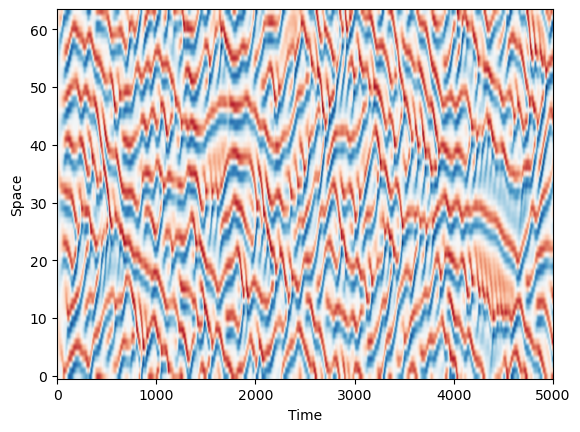

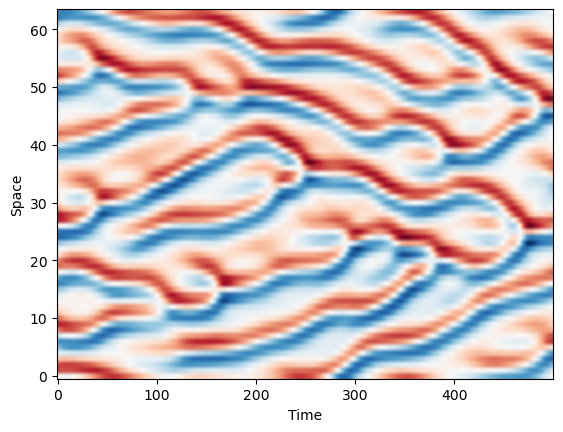

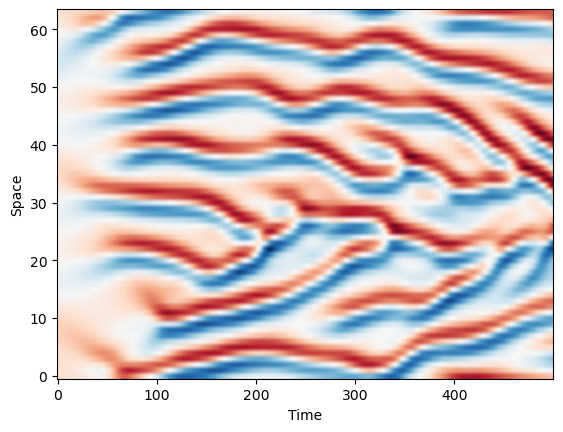

In [1]:
import jax
import exponax as ex
import matplotlib.pyplot as plt



num_points = 64
horizon = 5000
dt = 0.2
# ks_stepper = ex.stepper.Burgers (
#     num_spatial_dims=1, domain_extent=100.0,
#     num_points=num_points, dt=dt,
# )
#
ks_stepper = ex.stepper.KuramotoSivashinskyConservative(
    num_spatial_dims=1, domain_extent=64.0,
    num_points=num_points, dt=dt,
    order=3
)

# ks_stepper = ex.stepper.KuramotoSivashinsky (
#     num_spatial_dims=1, domain_extent=100.0,
#     num_points=num_points, dt=dt,
# )

# ks_stepper = ex.stepper.KuramotoSivashinsky (
#     num_spatial_dims=1, domain_extent=100.0,
#     num_points=num_points, dt=dt,
# )

for i in range(1):
    u_0 = (
        ex.ic.RandomTruncatedFourierSeries(
        num_spatial_dims=1, cutoff=5
    )(num_points=num_points, key=jax.random.PRNGKey(i)))


    trajectory = ex.rollout(ks_stepper, horizon, include_init=True)(u_0)

    plt.imshow(trajectory[:, 0, :].T, aspect='auto', cmap='RdBu', origin="lower")
    plt.xlabel("Time"); plt.ylabel("Space"); plt.show()

    plt.imshow(trajectory[3000:3500, 0, :].T, aspect='auto', cmap='RdBu', origin="lower")
    plt.xlabel("Time"); plt.ylabel("Space"); plt.show()
    plt.imshow(trajectory[000:500, 0, :].T, aspect='auto', cmap='RdBu', origin="lower")
    plt.xlabel("Time"); plt.ylabel("Space"); plt.show()
    # plt.imshow(trajectory[100:175, 0, :].T, aspect='auto', cmap='RdBu', origin="lower")
    # plt.xlabel("Time"); plt.ylabel("Space"); plt.show()
    # plt.imshow(trajectory[700:775, 0, :].T, aspect='auto', cmap='RdBu', origin="lower")
    # plt.xlabel("Time"); plt.ylabel("Space"); plt.show()

In [4]:
import dataset
import numpy as np

testdataset = dataset.KSDataset(degrade_interval=(8,1), discard_infeasible = True)


Total sample num: 50000
Remaining sample num: 19712


In [5]:
import torch
torch.cuda.memory_allocated() / 1024**3

0.6090860366821289

In [6]:
import dataset
# import numpy as np

# testdataset = dataset.KSDataset()
import PDFM
PDFlowMatching_class = PDFM.PDFlowMatching(testdataset)

### Seperately initialize $f_\phi$ (optional)

In [ ]:
ckpt = torch.load('./saved_model/PDE_FM_10000.pth', weights_only=True)
PDFlowMatching_class.model.load_state_dict(ckpt)
PDFlowMatching_class.train_prob_model(batch_size = 1000, lr = 1e-4, 
                                      training_epochs=10, init_ckpt_path = None, save_name = 'pmodeltest0p8.pth',
                                      inner_batch_size = 1000, t_val = 0.8)

### PDFM Case 1

In [ ]:
PDFlowMatching_class.PDFMtrain( max_epoches_per_lambda = 1000, batch_size_N = 500, target_csrate = 0.9, PD_lr = 2, para_lambda_init = None, 
                               PD_lr_decay = 0.95,
                  lr = 1e-6,
                  save_name="KS_PDFM2",
                  update_pmodel_every=10, init_ckpt_path='./saved_model/PDE_FM_10000.pth', FM_step_num=100, tval=-1,
                   patience = 50
        )

### PDFM Case 2

In [ ]:
PDFlowMatching_class.PDFMtrain( max_epoches_per_lambda = 1000, batch_size_N = 500, target_csrate = 0.9, PD_lr = 1, para_lambda_init = None, 
                               PD_lr_decay = 0.95,
                  lr = 1e-6,
                  save_name="KS_PDFM_degraded",
                  update_pmodel_every=10, init_ckpt_path='./saved_model/FM4degraded_10000.pth', FM_step_num=100, tval=-1,
                   patience = 50
        )

### FM

In [ ]:
PDFlowMatching_class.train_FM_lambda0(epoches = 10000, batch_size_N = 1000, save_every = 2000, lr = 1e-4, save_name = "FM4discard")